In [ ]:
# load a trained model
from pathlib import Path

import torch as tc

from models import ScatNet

device = tc.device("cuda")

SHAPE = (1, 100, 100)
model = ScatNet(shape=SHAPE).to(device)

model_state_path = Path("weights", f"{model.name}_fold0_best.pt")
model.load_state_dict(tc.load(model_state_path, weights_only=True))
model.eval()

ScatNet(
  (features): Scattering2D()
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6129, out_features=640, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=640, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [2]:
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as tvs

import numpy as np

transforms = tvs.Compose([
    tvs.Grayscale(),
    tvs.ToTensor(),
    tvs.Resize(100),
    tvs.CenterCrop(100),
    tvs.Normalize(mean=(0.5,), std=(0.5,)),
])

dataset = ImageFolder("data/cats_and_dogs/PetImages", transform=transforms)

CATS = [1, 501, 1001] #, 5001, 5002, 5003]
DOGS = [13001, 13002, 13003]
SAMPLES = CATS + DOGS
target_sample_loader = DataLoader(dataset, sampler=SAMPLES, batch_size=10)
images, true_labels = next(iter(target_sample_loader))
images, true_labels = images.to(device), true_labels.to(device)
pred_labels = (tc.sigmoid(model(images)) > 0.5).int().cpu()
print(pred_labels)

c:\Users\User\Desktop\ADR\Repository\xai-binary-classification\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


tensor([[0],
        [0],
        [1],
        [0],
        [1],
        [1]], dtype=torch.int32)


In [3]:
from captum.attr import Lime, Saliency, InputXGradient, GuidedBackprop, GuidedGradCam, Deconvolution, Occlusion, IntegratedGradients, NoiseTunnel

# keep it deterministic
tc.manual_seed(0)
np.random.seed(0)

attribution_methods = {
    "occlusion": Occlusion(model).attribute(images, target=None, sliding_window_shapes=(1, 10, 10), strides=2, baselines=0, perturbations_per_eval=1000),
    "lime": Lime(model).attribute(images, target=None, n_samples=5000, perturbations_per_eval=1000, show_progress=True),
    "saliency": NoiseTunnel(Saliency(model)).attribute(images, target=None, abs=False),
    "input x gradient": NoiseTunnel(InputXGradient(model)).attribute(images, target=None),
    "guided backprop": GuidedBackprop(model).attribute(images, target=None),
    # "guided gradcam": GuidedGradCam(model, layer=model.conv0).attribute(images, target=None),
    "deconvolution": Deconvolution(model).attribute(images, target=None),
    "integrated gradients": IntegratedGradients(model).attribute(images, target=None),
}

c:\Users\User\Desktop\ADR\Repository\xai-binary-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\Desktop\ADR\Repository\xai-binary-classification\.venv\Lib\site-packages\captum\attr\_core\lime.py:1169: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(
Lime attribution: 100%|██████████| 5/5 [00:04<00:00,  1.18it/s]
c:\Users\User\Desktop\ADR\Repository\xai-binary-classification\.venv\Lib\site-packages\captum\attr\_core\guided_backprop_deconvnet.py:63: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = app

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attribution(method: str, attributions):
    attributions = attributions.mean(dim=1).detach().cpu().numpy()
    fig, axes = plt.subplots(nrows=1, ncols=len(attributions), figsize=(25, 5))
    fig.suptitle(method)
    for i in range(len(attributions)):
        sns.heatmap(images[i].mean(dim=0).detach().cpu().numpy(), ax=axes[i], cmap='gray', alpha=1, cbar=False)
        sns.heatmap(attributions[i], ax=axes[i], cmap='seismic', alpha=0.3, vmax=np.abs(attributions[i]).max(), vmin=-np.abs(attributions[i]).max(), cbar=True)
        title = f"true: {dataset.classes[true_labels[i].item()]}, pred: {dataset.classes[pred_labels[i]]}"
        axes[i].set_title(title)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

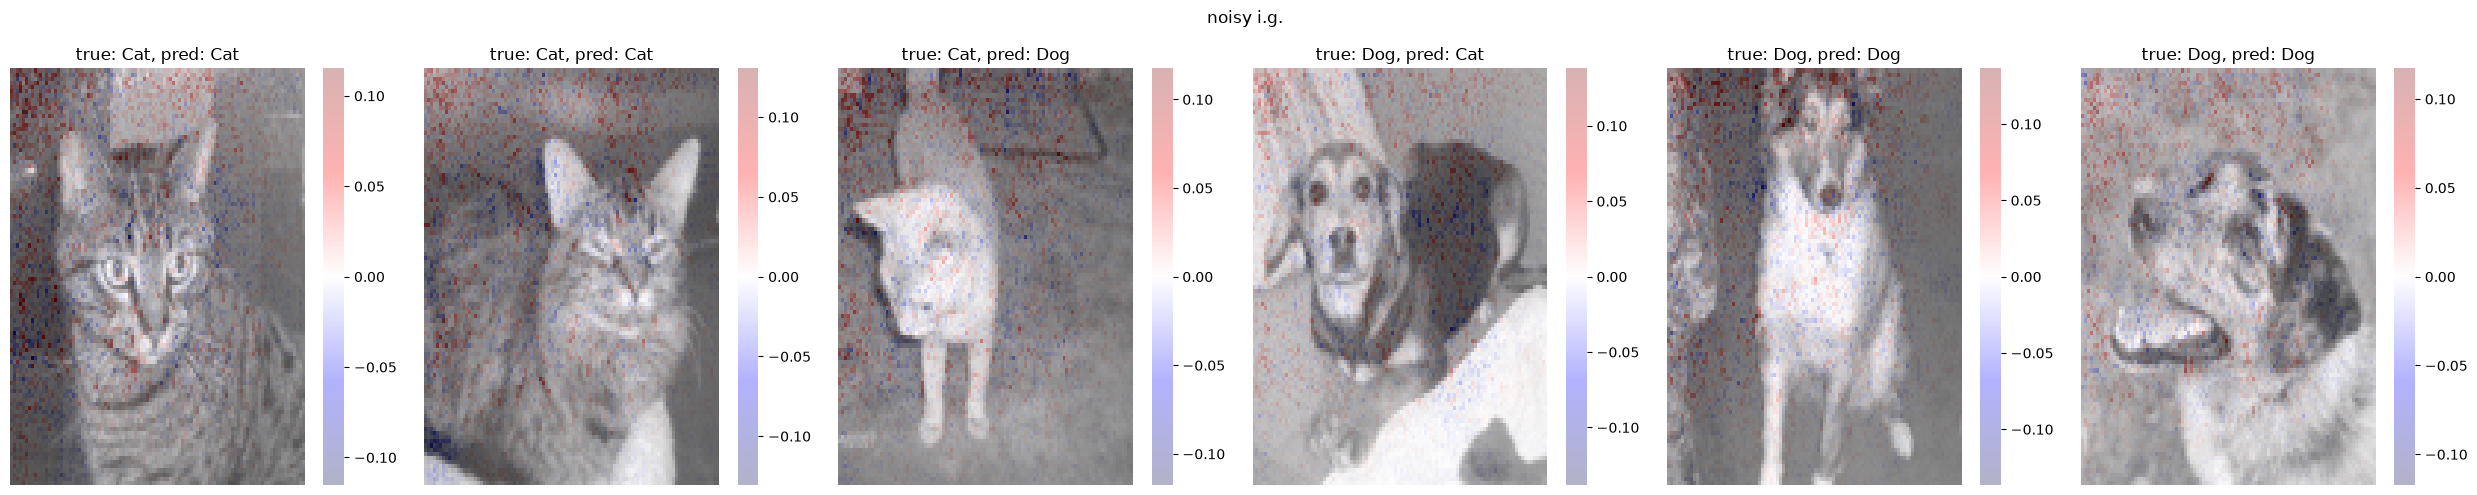

In [5]:
from captum.attr import NoiseTunnel, IntegratedGradients

# keep it deterministic
tc.manual_seed(0)
np.random.seed(0)

attribution = NoiseTunnel(IntegratedGradients(model)).attribute(images, target=None)
plot_attribution("noisy i.g.", attribution)

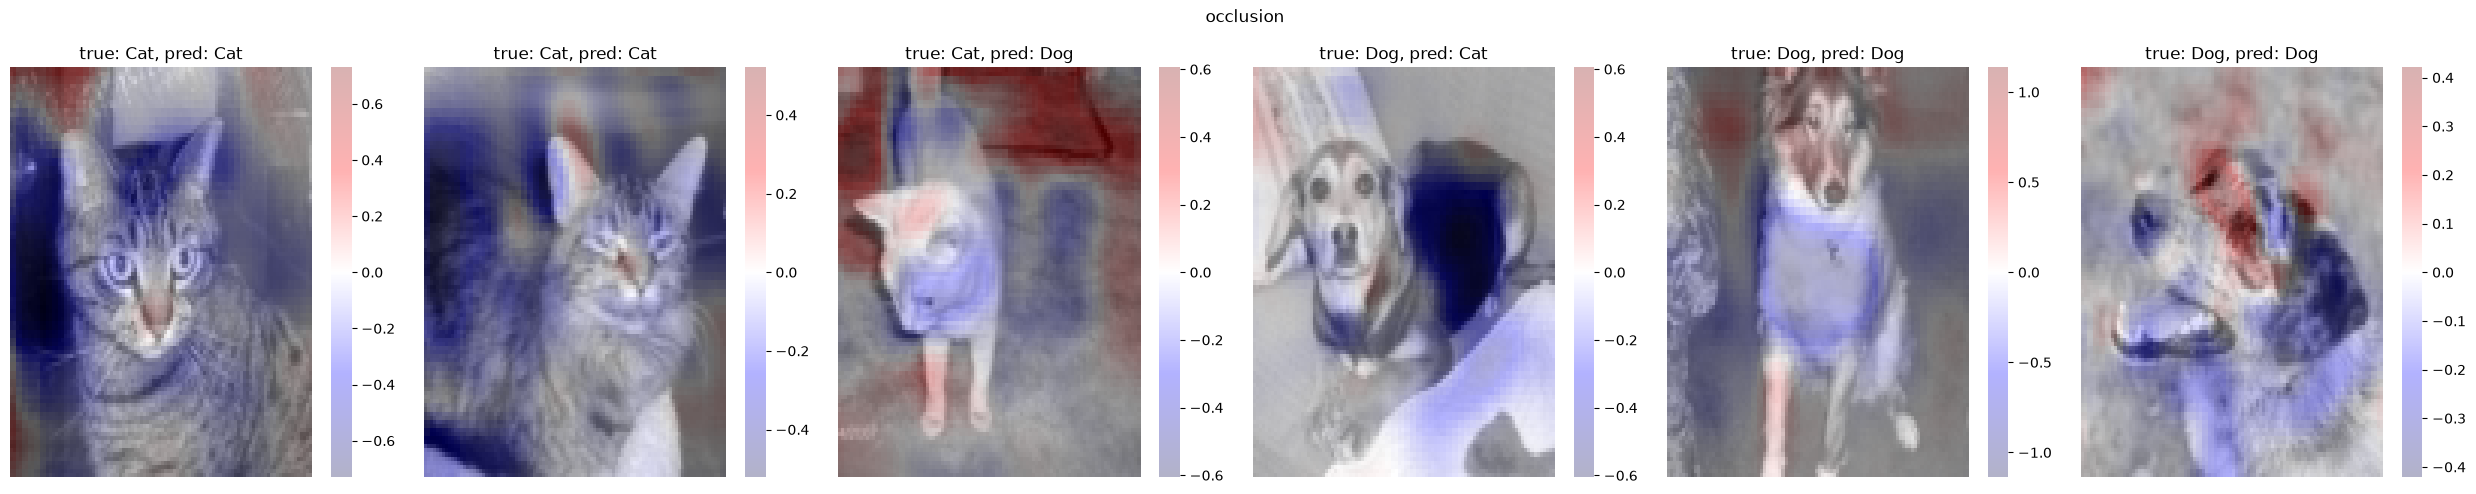

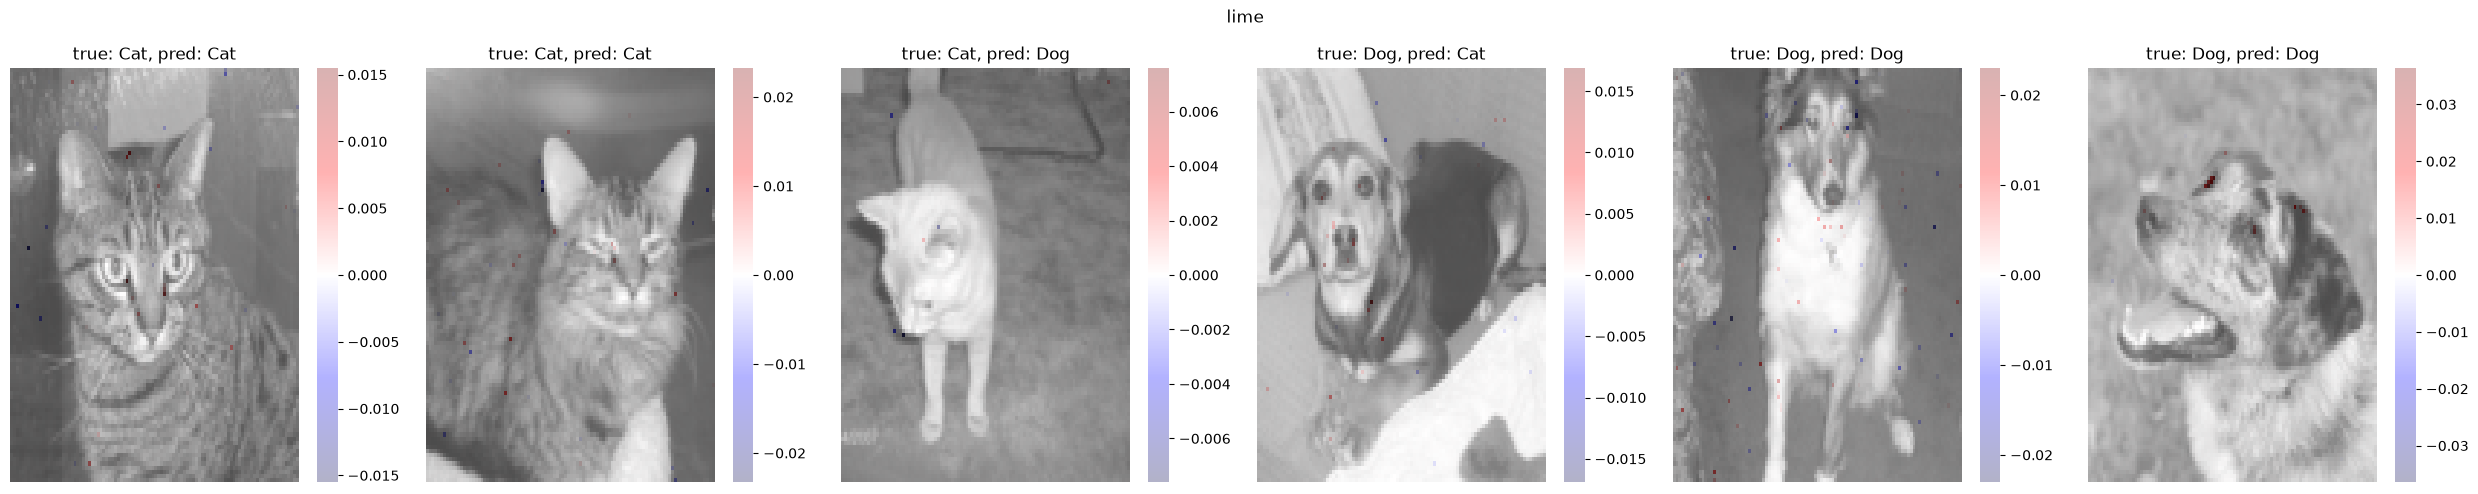

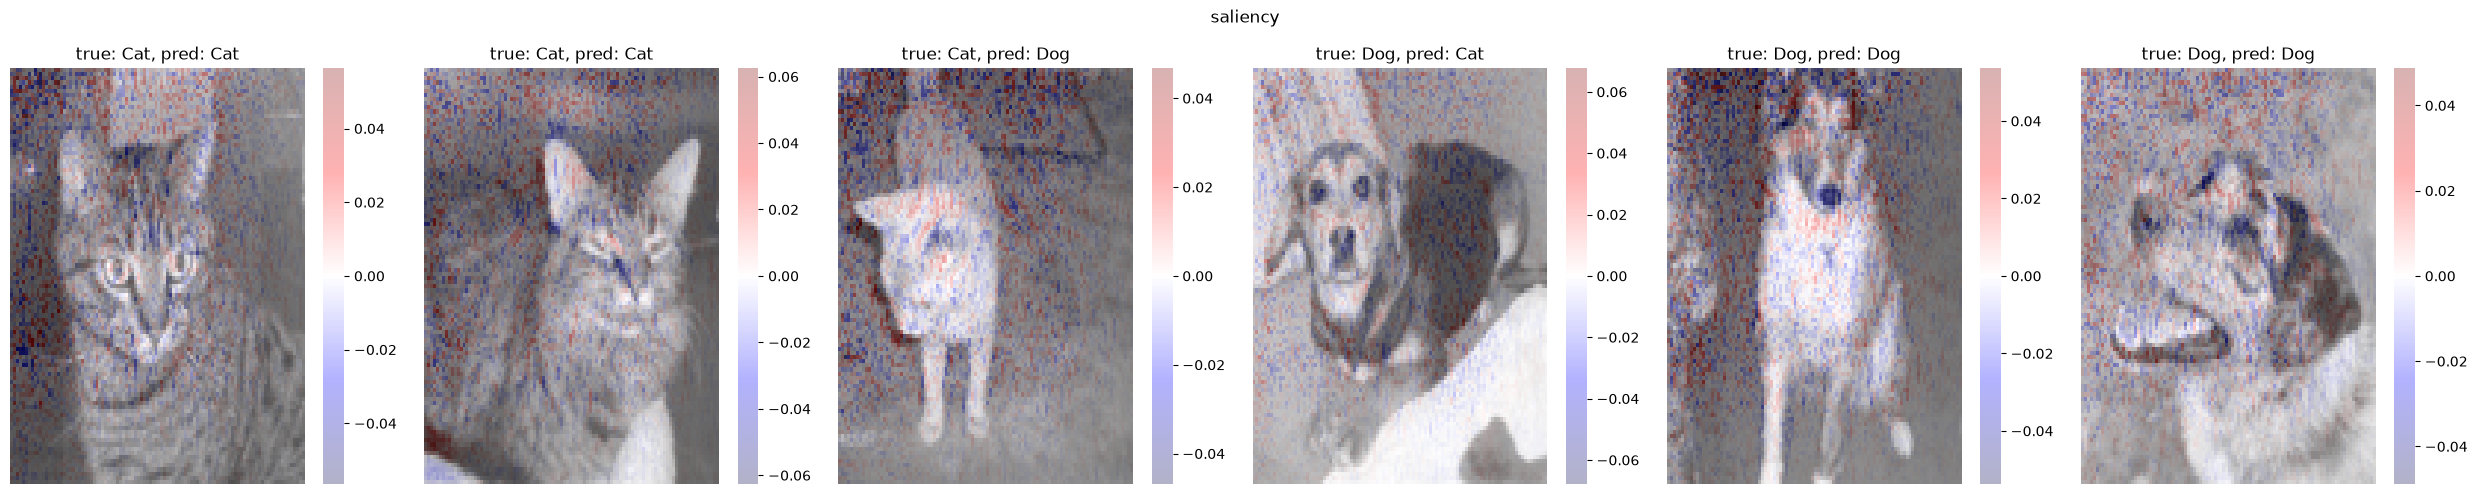

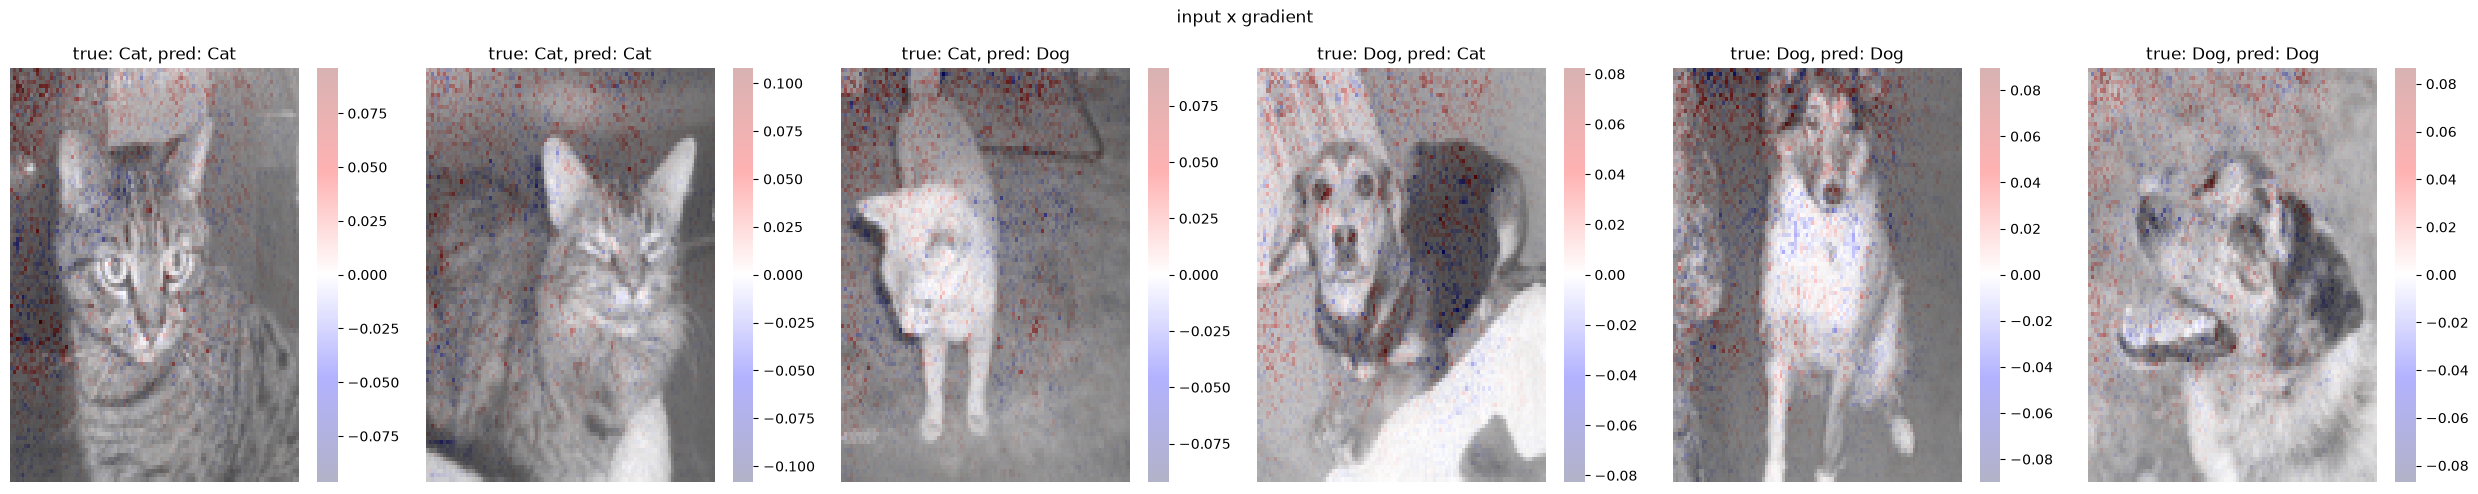

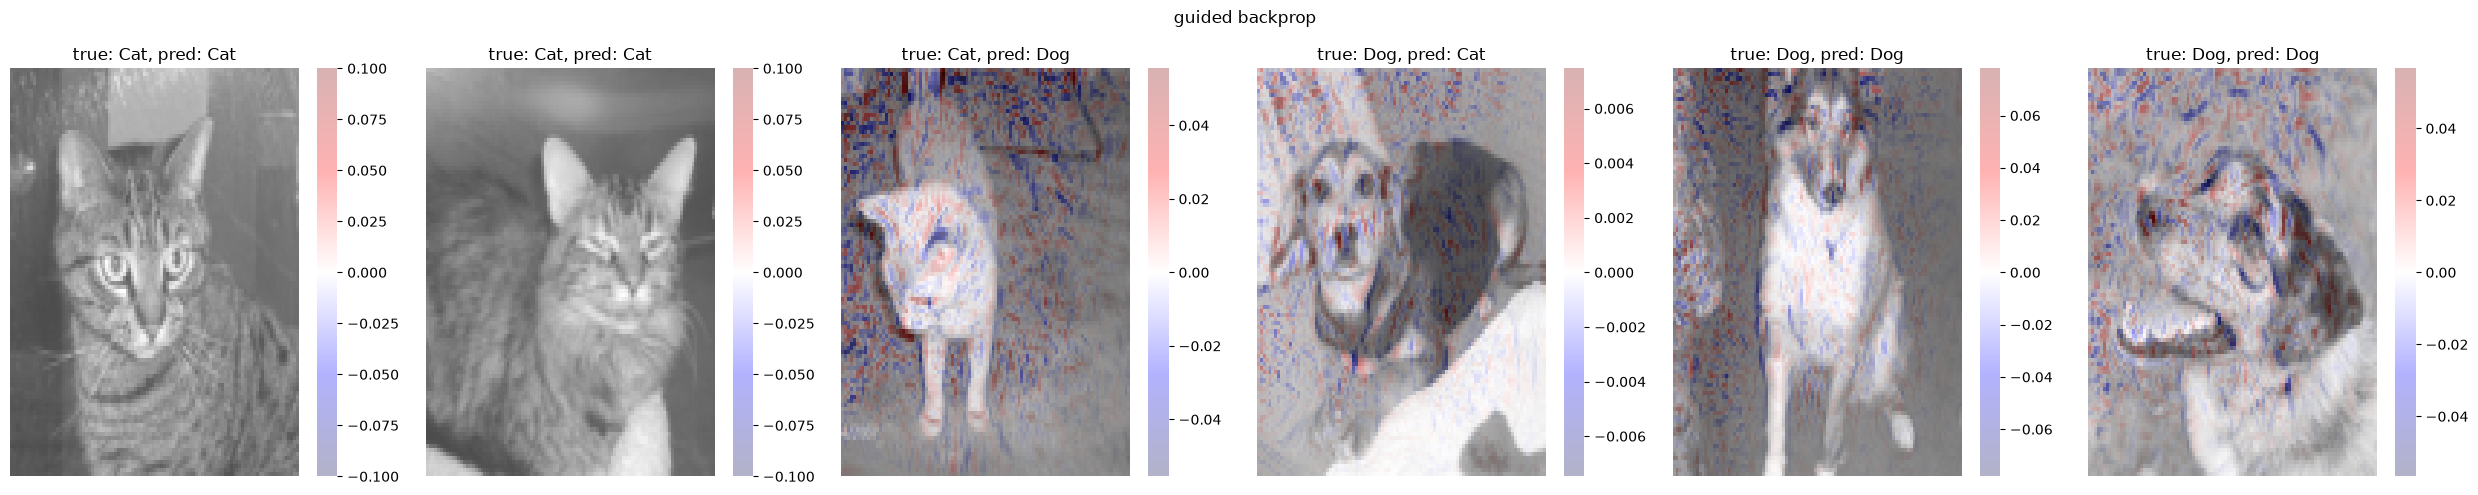

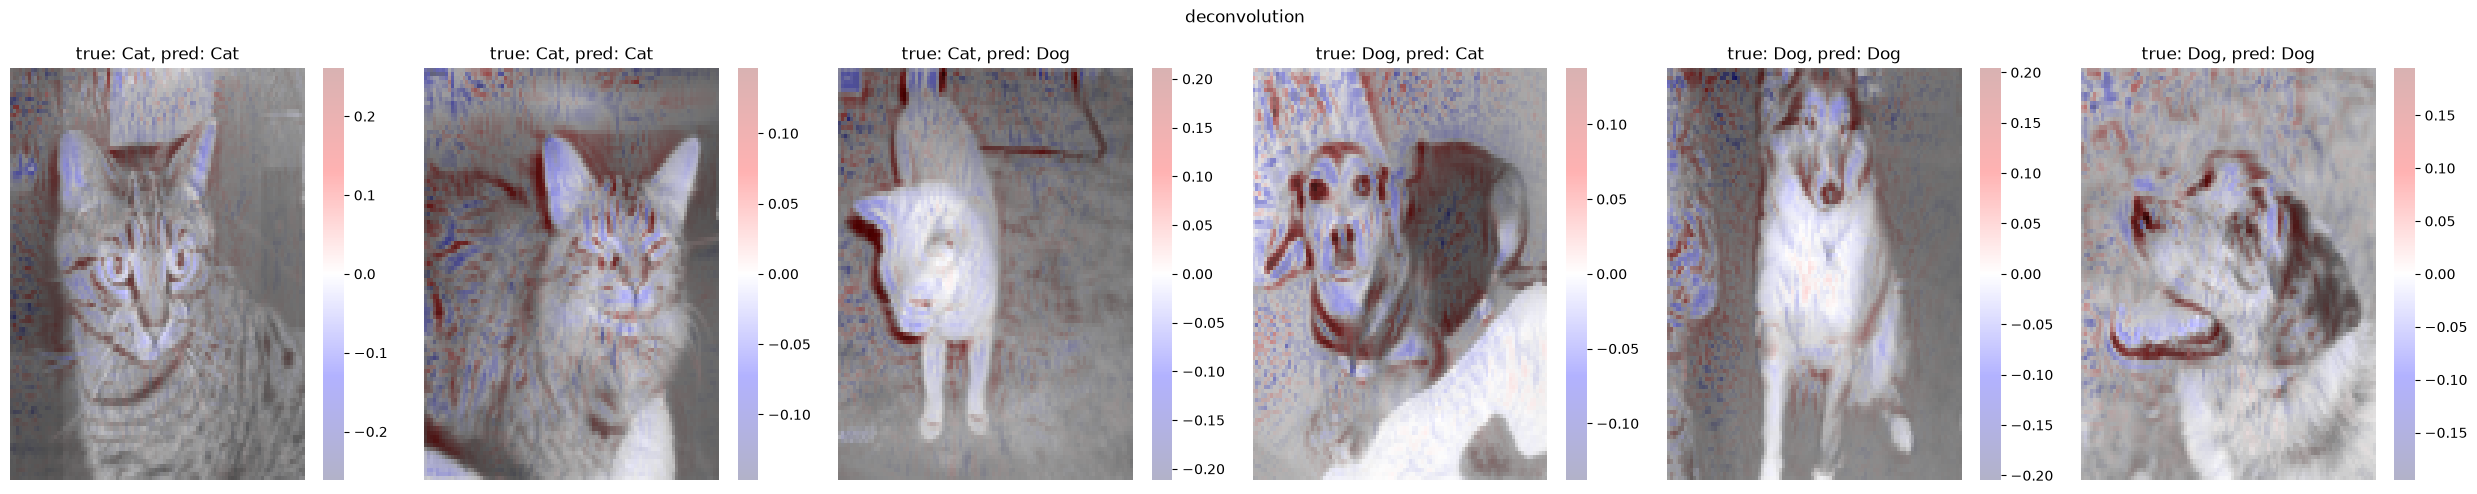

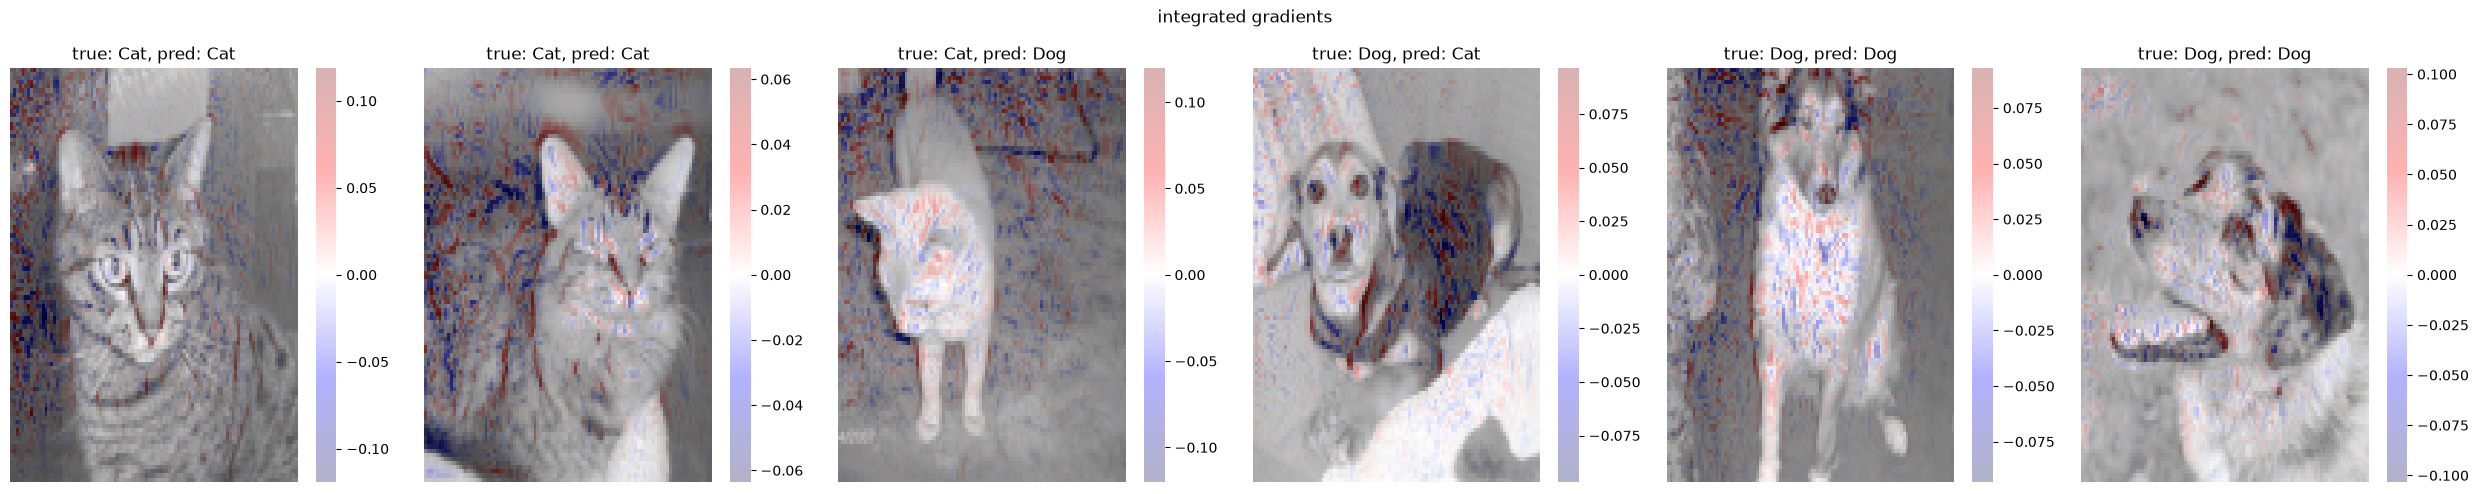

In [6]:
for method, attributions in attribution_methods.items():
    plot_attribution(method, attributions)

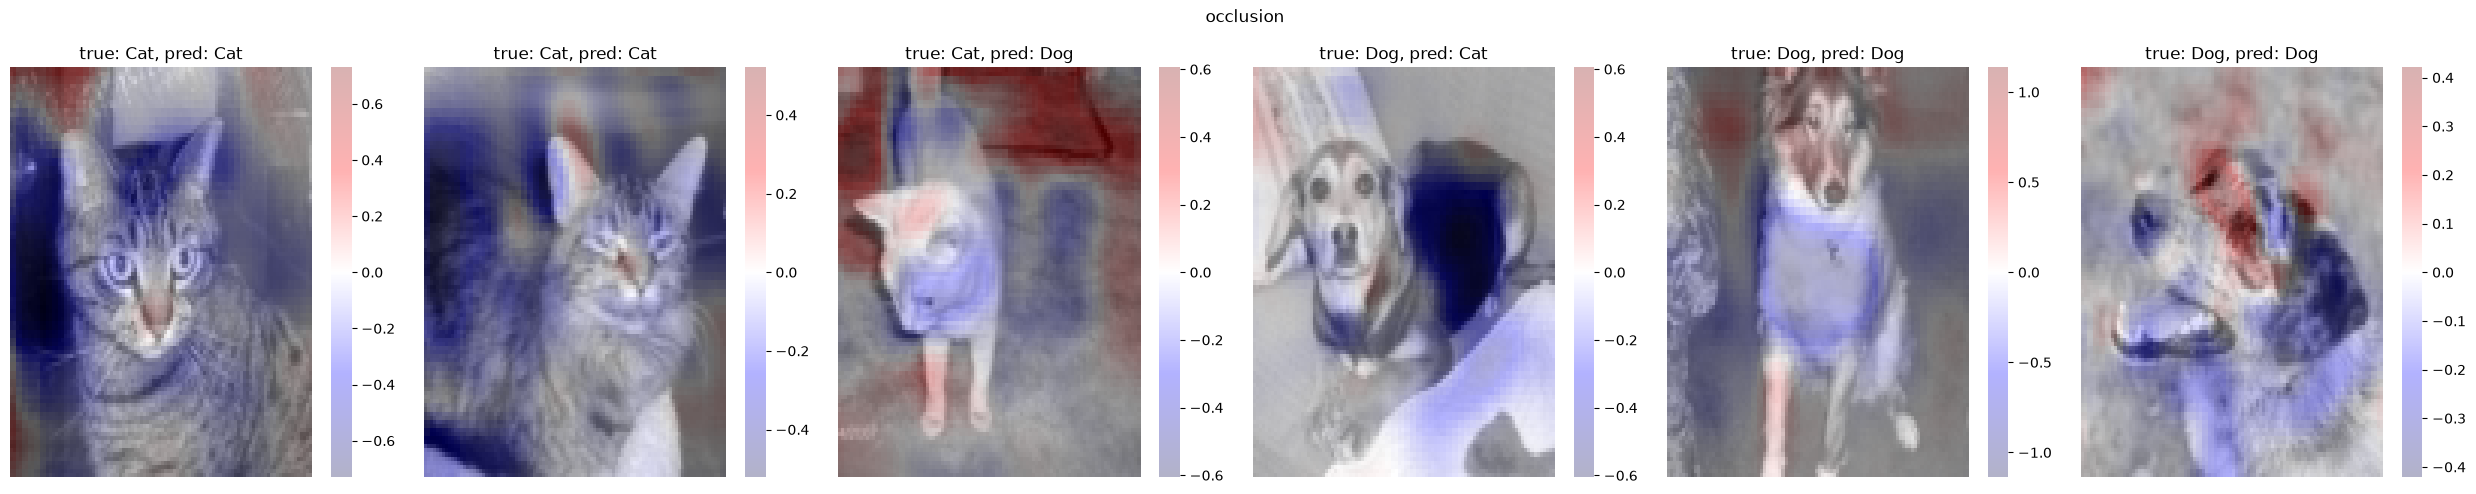

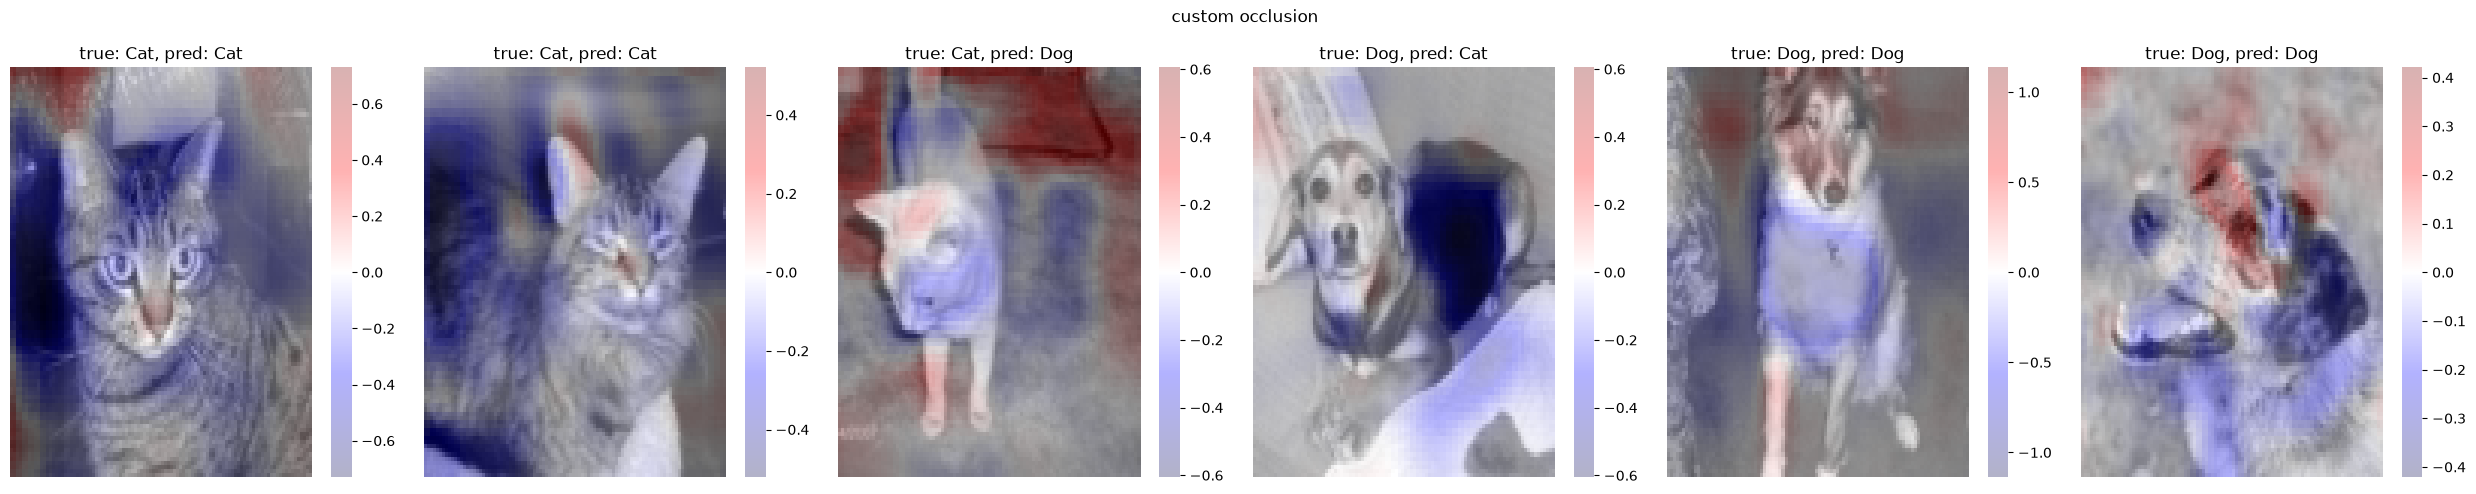

In [7]:
from occlusions import ImageOcclusion

custom_occlusion = ImageOcclusion()
custom_occlusion_attributions = []
for im in images:
    att = custom_occlusion.explain(model, im, window_shape=(10, 10), window_stride=(2, 2), baseline=0)
    custom_occlusion_attributions.append(att)

# pack the attributions and add channel dimension
custom_occlusion_attributions = tc.stack(custom_occlusion_attributions).unsqueeze(dim=1)

plot_attribution("occlusion", attribution_methods["occlusion"])
plot_attribution("custom occlusion", custom_occlusion_attributions)